معالجة مجلد: C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\train\images


100%|██████████| 9481/9481 [02:30<00:00, 63.09it/s] 


تم حذف 53 صورة (مكررة أو تالفة)


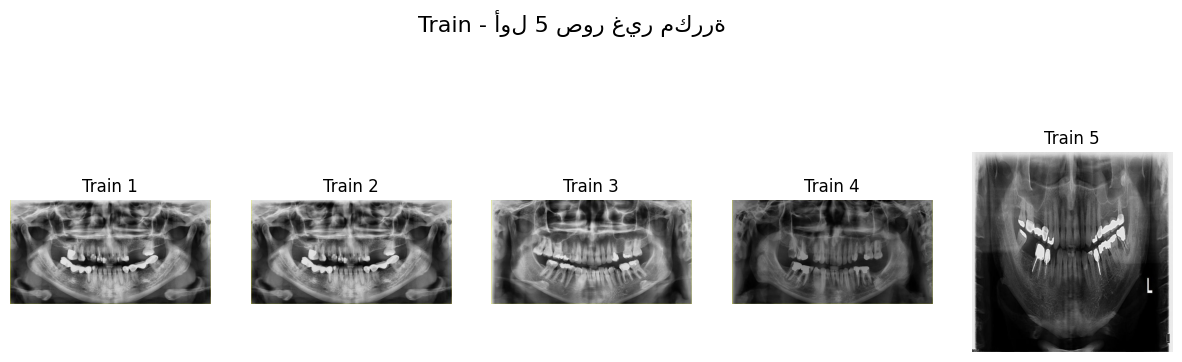

معالجة مجلد: C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\valid\images


100%|██████████| 2871/2871 [00:46<00:00, 62.16it/s]


تم حذف 0 صورة (مكررة أو تالفة)


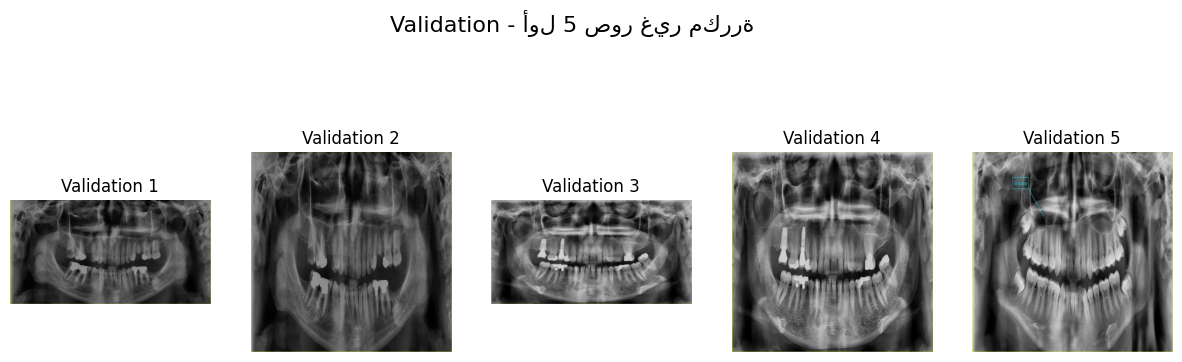

معالجة مجلد: C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\test\images


100%|██████████| 1580/1580 [00:24<00:00, 64.60it/s]


تم حذف 0 صورة (مكررة أو تالفة)


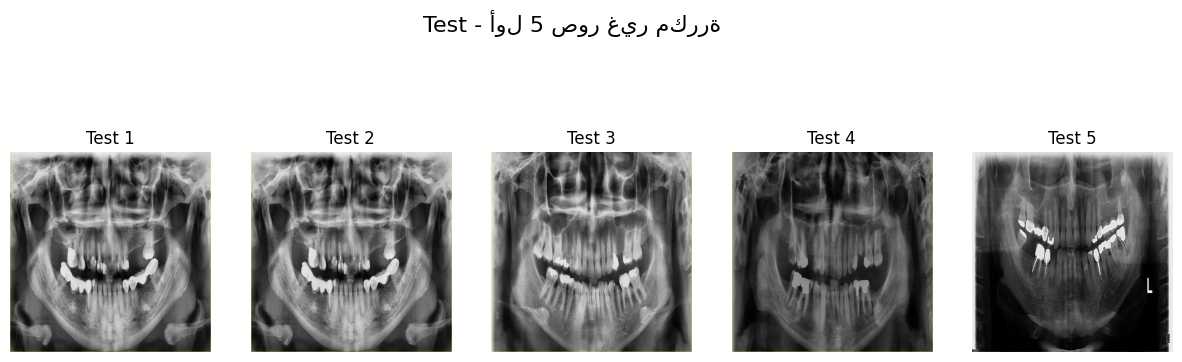

In [10]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import hashlib
from tqdm import tqdm  # لعرض شريط التقدم

def calculate_image_hash(image_path):
    """حساب بصمة الصورة للكشف عن المكرر"""
    with open(image_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def is_valid_image(image_path):
    """فحص إذا كانت الصورة صالحة وغير فارغة"""
    try:
        img = Image.open(image_path)
        img.verify()  # التحقق من أن الصورة غير تالفة
        if img.width == 0 or img.height == 0:  # التحقق من أن الصورة غير فارغة
            return False
        return True
    except (IOError, SyntaxError):
        return False

def process_folder(folder_path, max_images=5):
    """معالجة المجلد وحذف المكرر والفارغ"""
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    unique_images = {}
    removed_count = 0
    
    print(f"معالجة مجلد: {folder_path}")
    for file in tqdm(image_files):
        img_path = os.path.join(folder_path, file)
        
        # التحقق من أن الصورة صالحة
        if not is_valid_image(img_path):
            os.remove(img_path)  # حذف الصورة الفارغة/التالفة
            removed_count += 1
            continue
            
        # حساب بصمة الصورة للكشف عن المكرر
        img_hash = calculate_image_hash(img_path)
        
        if img_hash not in unique_images:
            unique_images[img_hash] = img_path
        else:
            os.remove(img_path)  # حذف الصورة المكررة
            removed_count += 1
    
    print(f"تم حذف {removed_count} صورة (مكررة أو تالفة)")
    return list(unique_images.values())[:max_images]

def show_images(image_paths, title):
    """عرض الصور"""
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(image_paths):
        img = Image.open(img_path)

        plt.subplot(1, len(image_paths), i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{title} {i+1}")

    plt.suptitle(f"{title} - أول {len(image_paths)} صور غير مكررة", fontsize=16)
    plt.show()

# تعريف المسارات:
train_path = r"C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\train\images"
val_path = r"C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\valid\images"
test_path = r"C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\test\images"

# معالجة وعرض الصور:
train_images = process_folder(train_path)
show_images(train_images, "Train")

val_images = process_folder(val_path)
show_images(val_images, "Validation")

test_images = process_folder(test_path)
show_images(test_images, "Test")